In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving wgidataset.xlsx to wgidataset.xlsx
User uploaded file "wgidataset.xlsx" with length 3111893 bytes


In [ ]:
import pandas as pd

# Assuming 'uploaded' is defined from the previous code cell
for fn in uploaded.keys():
  if fn.endswith('.xlsx') or fn.endswith('.xls'):  # Check for Excel file extensions
    try:
      df = pd.read_excel(fn)
      print(f"\nDetails of file: {fn}")
      print(df.head())  # Print the first few rows
      print(df.info())  # Print data types and non-null values
      print(df.describe()) # Print descriptive statistics
    except Exception as e:
      print(f"Error reading {fn}: {e}")
  else:
      print(f"File {fn} is not an Excel file.")



Details of file: wgidataset.xlsx
   codeindyr code     countryname  year indicator  estimate    stddev nsource  \
0  AFGcc1996  AFG     Afghanistan  1996        cc -1.291705  0.340507       2   
1  ALBcc1996  ALB         Albania  1996        cc -0.893903  0.315914       3   
2  DZAcc1996  DZA         Algeria  1996        cc -0.566741  0.262077       4   
3  ASMcc1996  ASM  American Samoa  1996        cc        ..        ..      ..   
4  ADOcc1996  ADO         Andorra  1996        cc  1.318143  0.480889       1   

     pctrank pctranklower pctrankupper  
0   4.301075            0    27.419355  
1  19.354839     2.688172    43.010754  
2  33.333332    16.666666    52.688171  
3         ..           ..           ..  
4  87.096771    72.043015    96.774193  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32100 entries, 0 to 32099
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   codeindyr     32100 non-null  objec

In [ ]:
import pandas as pd

# Load the file
df = pd.read_excel("wgidataset.xlsx")

# Convert estimate column to numeric
df['estimate'] = pd.to_numeric(df['estimate'], errors='coerce')

# Pivot to wide format: each row = one country-year, each column = one indicator
df_wide = df.pivot_table(
    values='estimate',
    index=['countryname', 'year'],
    columns='indicator'
).reset_index()

# Drop rows where the target (Political Stability - 'pv') is missing
df_wide = df_wide.dropna(subset=['pv'])

# Fill remaining missing values ONLY in numeric indicator columns
indicator_cols = ['cc', 'ge', 'rl', 'rq', 'va']  # exclude 'pv' because it's the target
df_wide[indicator_cols] = df_wide[indicator_cols].fillna(df_wide[indicator_cols].mean())


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df = pd.read_excel("wgidataset.xlsx")

# Convert estimate to numeric
df['estimate'] = pd.to_numeric(df['estimate'], errors='coerce')

# Pivot to wide format
df_wide = df.pivot_table(values='estimate', index=['countryname', 'year'], columns='indicator').reset_index()

# Drop rows where 'pv' (political stability) is missing
df_wide = df_wide.dropna(subset=['pv'])

# Fill missing values in features
features = ['cc', 'ge', 'rl', 'rq', 'va']
df_wide[features] = df_wide[features].fillna(df_wide[features].mean())

# Define input (X) and target (y)
X = df_wide[features]
y = df_wide['pv']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print("R² Score:", r2)
print("Root Mean Squared Error (RMSE):", rmse)


R² Score: 0.8216388663774546
Root Mean Squared Error (RMSE): 0.41198929589685074


In [ ]:
def predict_stability(country, year):
    # Filter the latest available data for the country and year
    row = df[(df['countryname'] == country) & (df['year'] == year)]

    # If the country-year isn't available, fallback to latest year for that country
    if row.empty:
        row = df[df['countryname'] == country].sort_values(by='year', ascending=False).head(6)

    # Pivot to wide format for the given country-year
    row_wide = row.pivot(index='countryname', columns='indicator', values='estimate')

    # Convert estimates to numeric
    row_wide = row_wide.apply(pd.to_numeric, errors='coerce')

    # Extract required features
    row_input = row_wide[['cc', 'ge', 'rl', 'rq', 'va']]

    # Fill missing with column means (same as training)
    row_input = row_input.fillna(df_wide[['cc', 'ge', 'rl', 'rq', 'va']].mean())

    # Predict
    predicted_pv = model.predict(row_input)[0]

    print(f"\nPredicted Political Stability (pv) for {country} in {year}: {predicted_pv:.3f}")

# Example:
predict_stability("Brazil", 2022)



Predicted Political Stability (pv) for Brazil in 2022: 0.390


<ipython-input-6-b34a52670d5f>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_data['estimate'] = pd.to_numeric(country_data['estimate'], errors='coerce')


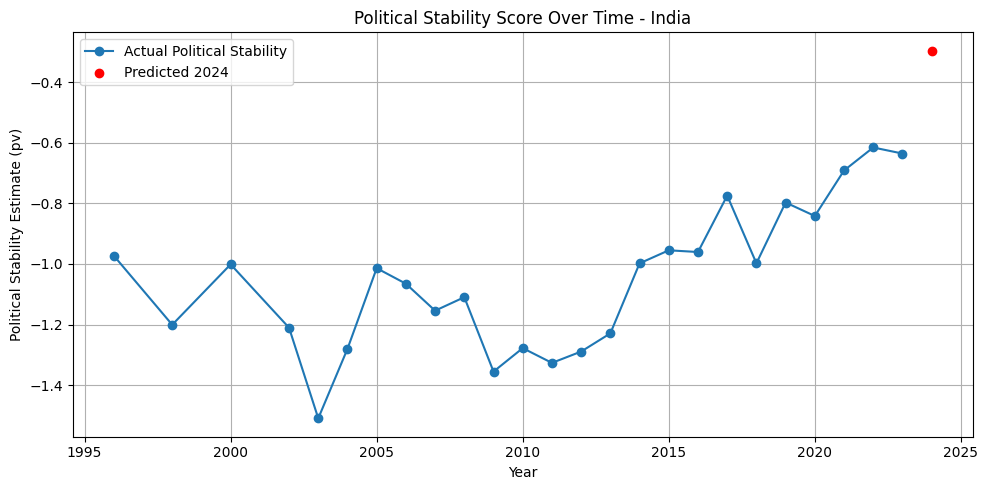

In [ ]:
import matplotlib.pyplot as plt

def plot_stability_trend(country, predict_year=None):
    # Filter actual data for the country
    country_data = df[(df['countryname'] == country) & (df['indicator'] == 'pv')]
    country_data['estimate'] = pd.to_numeric(country_data['estimate'], errors='coerce')
    country_data = country_data.dropna(subset=['estimate'])

    # Sort by year
    country_data = country_data.sort_values(by='year')

    # Plot actual stability over time
    plt.figure(figsize=(10, 5))
    plt.plot(country_data['year'], country_data['estimate'], marker='o', label='Actual Political Stability')

    # Predict and plot the given year (if applicable)
    if predict_year is not None:
        try:
            row = df[(df['countryname'] == country) & (df['year'] == predict_year)]
            if row.empty:
                row = df[df['countryname'] == country].sort_values(by='year', ascending=False).head(6)

            row_wide = row.pivot(index='countryname', columns='indicator', values='estimate')
            row_wide = row_wide.apply(pd.to_numeric, errors='coerce')
            row_input = row_wide[['cc', 'ge', 'rl', 'rq', 'va']].fillna(df_wide[['cc', 'ge', 'rl', 'rq', 'va']].mean())

            predicted_pv = model.predict(row_input)[0]
            plt.scatter(predict_year, predicted_pv, color='red', zorder=5, label=f'Predicted {predict_year}')
        except:
            print("Could not generate prediction for the graph.")

    plt.title(f"Political Stability Score Over Time - {country}")
    plt.xlabel("Year")
    plt.ylabel("Political Stability Estimate (pv)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example:
plot_stability_trend("India", predict_year=2024)


In [ ]:


import pickle

# Save the model to a file
filename = 'finalized_model.sav'
pickle.dump(model, open(filename, 'wb'))

# Download the saved model
from google.colab import files
files.download(filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def normalized_percentage(score, min_val=-2.5, max_val=2.5):
    """Normalize World Governance Indicator score to 0–100% scale."""
    return ((score - min_val) / (max_val - min_val)) * 100

def get_prediction_and_plot():
    country = input("Enter a country name (e.g., India): ").strip()
    year = int(input("Enter a year (e.g., 2024): "))

    # Filter relevant data
    row = df[(df['countryname'] == country) & (df['year'] == year)]
    if row.empty:
        row = df[df['countryname'] == country].sort_values(by='year', ascending=False).head(6)

    row_wide = row.pivot(index='countryname', columns='indicator', values='estimate')
    row_wide = row_wide.apply(pd.to_numeric, errors='coerce')
    row_input = row_wide[['cc', 'ge', 'rl', 'rq', 'va']].fillna(df_wide[['cc', 'ge', 'rl', 'rq', 'va']].mean())

    # Predict
    predicted_pv = model.predict(row_input)[0]
    predicted_pct = normalized_percentage(predicted_pv)

    print(f"\nPredicted Political Stability (pv) for {country} in {year}:")
    print(f"Raw Score: {predicted_pv:.3f}")
    print(f"Normalized Score: {predicted_pct:.2f}%")

    # Plot historical trend
    country_data = df[(df['countryname'] == country) & (df['indicator'] == 'pv')]
    country_data['estimate'] = pd.to_numeric(country_data['estimate'], errors='coerce')
    country_data = country_data.dropna(subset=['estimate']).sort_values(by='year')

    plt.figure(figsize=(10, 5))
    plt.plot(country_data['year'], country_data['estimate'], marker='o', label='Actual Political Stability')
    plt.scatter(year, predicted_pv, color='red', zorder=5, label=f'Predicted {year} ({predicted_pct:.1f}%)')

    plt.title(f"Political Stability Over Time – {country}")
    plt.xlabel("Year")
    plt.ylabel("Stability Score (pv)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Enter a country name (e.g., India): Australia
Enter a year (e.g., 2024): 2025

Predicted Political Stability (pv) for Australia in 2025:
Raw Score: 0.915
Normalized Score: 68.30%


<ipython-input-7-68eebd184f66>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_data['estimate'] = pd.to_numeric(country_data['estimate'], errors='coerce')


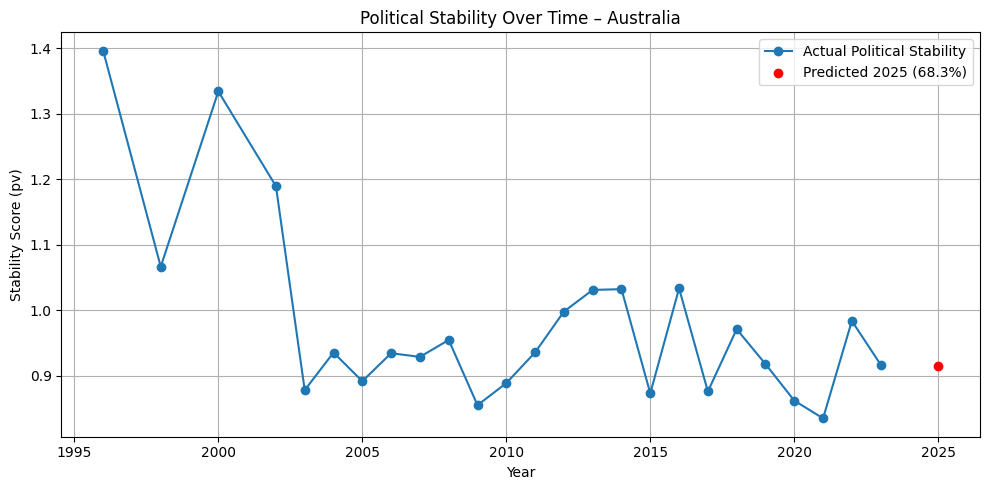

In [ ]:
get_prediction_and_plot()
